<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 1 (effective batch size ≈ 16, tuned value = 17)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 1.43e-04 | train loss 1.4674 acc 0.530 | val loss 0.7932 acc 0.685 *


[InceptionNet v3] Epoch   2/100 | LR: 1.43e-04 | train loss 1.0539 acc 0.649 | val loss 0.5757 acc 0.739 *


[InceptionNet v3] Epoch   3/100 | LR: 1.43e-04 | train loss 0.7219 acc 0.778 | val loss 0.5446 acc 0.764 *


[InceptionNet v3] Epoch   4/100 | LR: 1.43e-04 | train loss 0.6432 acc 0.801 | val loss 0.5868 acc 0.783


[InceptionNet v3] Epoch   5/100 | LR: 1.43e-04 | train loss 0.4521 acc 0.833 | val loss 0.5695 acc 0.783


...

[InceptionNet v3] Epoch  18/100 | LR: 1.43e-04 | train loss 0.2390 acc 0.942 | val loss 0.9898 acc 0.823


[InceptionNet v3] Epoch  19/100 | LR: 1.43e-04 | train loss 0.2120 acc 0.950 | val loss 0.7143 acc 0.842


[InceptionNet v3] Epoch  20/100 | LR: 1.43e-04 | train loss 0.6151 acc 0.937 | val loss 0.7006 acc 0.842


[InceptionNet v3] Epoch  21/100 | LR: 1.43e-05 | train loss 0.1211 acc 0.965 | val loss 0.5412 acc 0.867


[InceptionNet v3] Epoch  22/100 | LR: 1.43e-05 | train loss 0.0661 acc 0.981 | val loss 0.6421 acc 0.872

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 22.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4599)


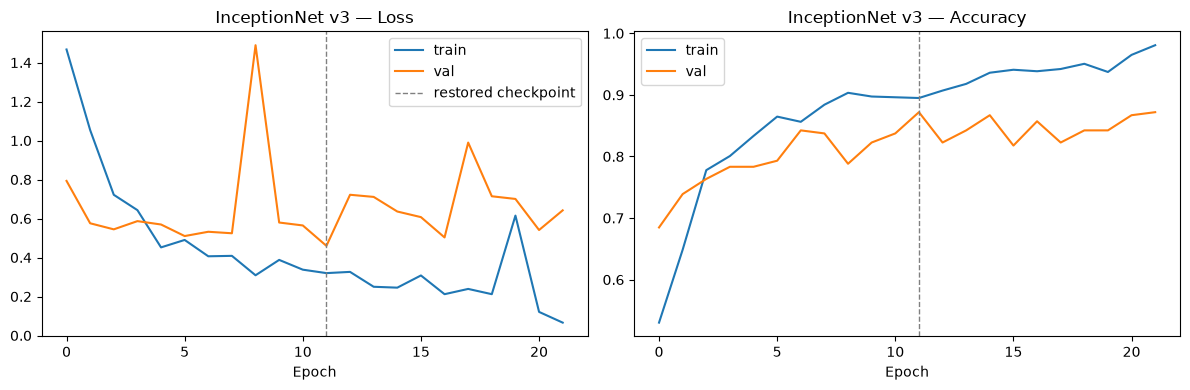

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.720


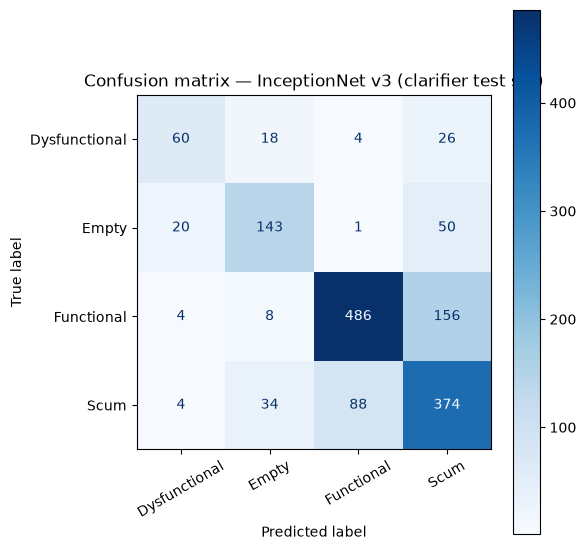

               precision    recall  f1-score   support

Dysfunctional      0.682     0.556     0.612       108
        Empty      0.704     0.668     0.686       214
   Functional      0.839     0.743     0.788       654
         Scum      0.617     0.748     0.676       500

     accuracy                          0.720      1476
    macro avg      0.711     0.679     0.691      1476
 weighted avg      0.733     0.720     0.723      1476



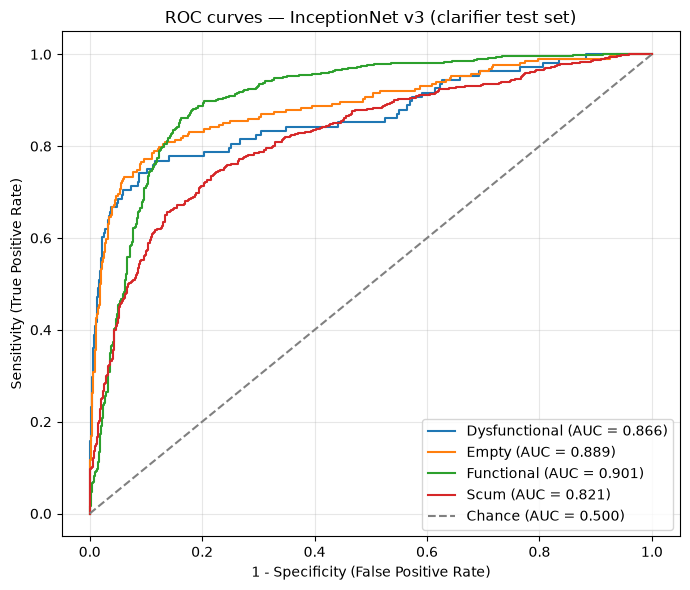

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.866
  Empty          : 0.889
  Functional     : 0.901
  Scum           : 0.821

Mean AUC (over 4/4 classes with test examples): 0.869


(np.float64(0.7201897018970189),
 {'Dysfunctional': 0.865524149880875,
  'Empty': 0.8887465379089711,
  'Functional': 0.9007864758885986,
  'Scum': 0.820639344262295})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_clarifier_inception_v3_CapeFlats.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
